# German Credit Data – Exploratory Data Analysis and Modeling

## Objective
The goal of this analysis is to explore borrower characteristics and identify and model patterns associated with credit risk (good vs. bad).

## Business Context
This analysis is framed in a retail banking context, focusing on interpretable insights relevant for credit risk assessment.

In [1]:
#importing packages and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_cleaning import prepare_data
from src.data_analysis import analyse_feature, ctbplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve


pal='colorblind'

sns.set_theme(
    style='ticks',
    palette=pal,
    rc={
        'figure.figsize':   (10, 5),
        'figure.dpi':       120,
        'axes.spines.top':  False,
        'axes.spines.right': False,
        "axes.prop_cycle":   plt.cycler(color=sns.color_palette(pal).as_hex())
    }
)

In [2]:
#reading the dataset
original_data = pd.read_csv('../data/raw/SouthGermanCredit.asc', sep =' ')
#preparing data using the codetable
code_table = '../data/raw/codetable.txt'
df = prepare_data(original_data,code_table)
#checking first rows
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,2-3,skilled employee/official,3 or more,no,no,good
2,... < 0 DM,12,no credits taken/all credits paid back duly,retraining,841,... < 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,2-3,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,2-3,unskilled - resident,0 to 2,no,yes,good


## Data Overview

We start by inspecting the dataset structure, data types, and potential data quality issues.

In [3]:
#checking data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   status                   1000 non-null   category
 1   duration                 1000 non-null   int64   
 2   credit_history           1000 non-null   category
 3   purpose                  1000 non-null   category
 4   amount                   1000 non-null   int64   
 5   savings                  1000 non-null   category
 6   employment_duration      1000 non-null   category
 7   installment_rate         1000 non-null   category
 8   personal_status_sex      1000 non-null   category
 9   other_debtors            1000 non-null   category
 10  present_residence        1000 non-null   category
 11  property                 1000 non-null   category
 12  age                      1000 non-null   int64   
 13  other_installment_plans  1000 non-null   category
 14  housing             

In [4]:
#check for duplicate rows
df.duplicated().any()

np.False_

In [5]:
#summary statistics numeric
df.describe(include='number')

,duration,amount,age
count,1000.000000,1000.00000,1000.00000
mean,20.903000,3271.24800,35.54200
std,12.058814,2822.75176,11.35267
min,4.000000,250.00000,19.00000
25%,12.000000,1365.50000,27.00000
50%,18.000000,2319.50000,33.00000
75%,24.000000,3972.25000,42.00000
max,72.000000,18424.00000,75.00000


In [6]:
#summary statistics categorical
df.describe(include='category')

,status,credit_history,purpose,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,4,3,4,4,3,3,4,4,2,2,2,2
top,... >= 200 DM / salary for at least 1 year,no credits taken/all credits paid back duly,furniture/equipment,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,>= 7 yrs,building soc. savings agr./life insurance,none,rent,1,skilled employee/official,0 to 2,no,no,good
freq,394,530,280,603,339,476,548,907,413,332,814,714,633,630,845,596,963,700


 **Summary**:
- the average **age** is 35.54 with standard deviation of 11.37 years
- the average **credit amount** is 3271.26 DM with standard deviation of 2822.74 DM
- the average **credit duration** is 20.90 years with standard deviation of 12.06 years

## Data Plausibility & Feature Relationships

Before analyzing credit risk, we examine relationships between key variables
to validate data consistency and better understand the structure of the portfolio.
We also include a short univariate Analysis of numerical variables.

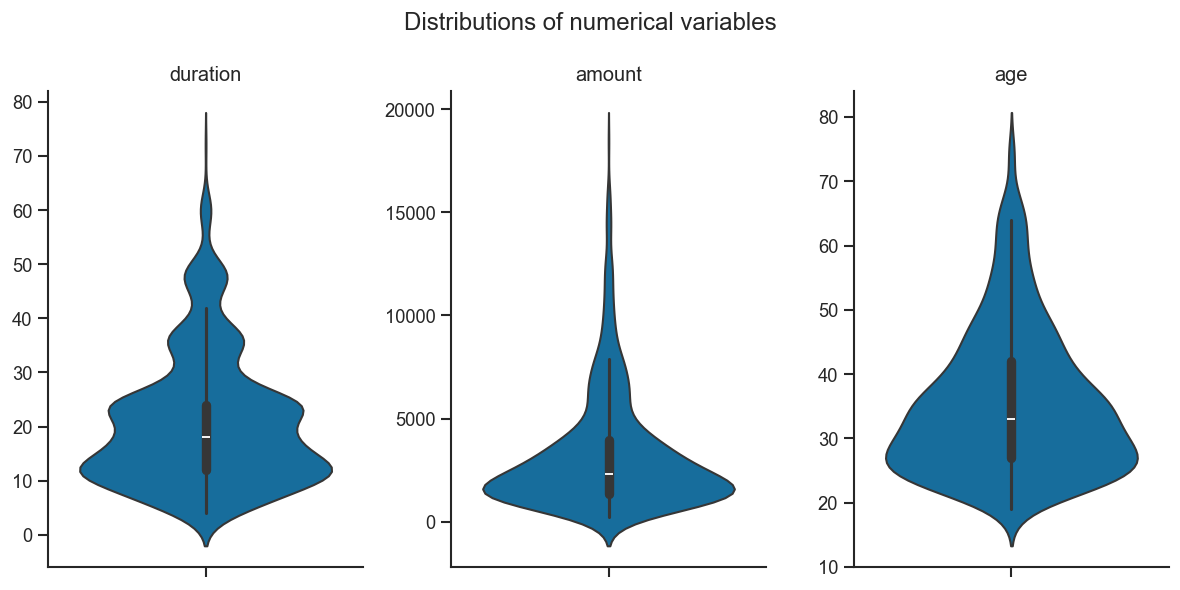

In [7]:
#plotting distributions for numeric variables
i=1
for col in df.select_dtypes('number').columns:
    plt.subplot(1,3,i)
    sns.violinplot(data = df, y = col)
    plt.title(col)
    plt.ylabel(None)
    i += 1

plt.suptitle('Distributions of numerical variables')
plt.tight_layout()

Text(0.5, 1.05, 'Pairplot of numerical variables')

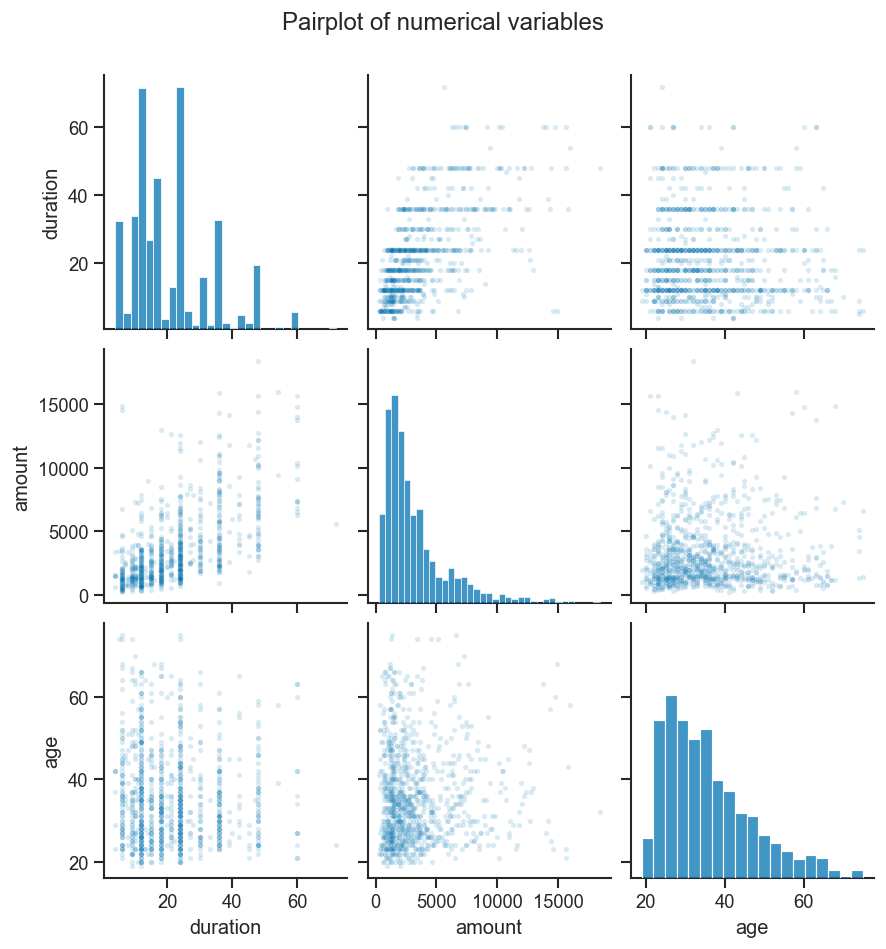

In [8]:
sns.pairplot(data=df.select_dtypes('number'),plot_kws={'s': 10, 'alpha': 0.15})
plt.suptitle('Pairplot of numerical variables',y=1.05)

In [9]:
#skewness and kurtosis
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    print(f'{col}: Skewness: {df[col].skew()}, Kurtosis: {df[col].kurt()}')

duration: Skewness: 1.0941841715555418, Kurtosis: 0.9197813600546372
amount: Skewness: 1.9495942869127831, Kurtosis: 4.292480607275049
age: Skewness: 1.0247120249859745, Kurtosis: 0.6205294816308626


Text(0.5, 1.0, 'Correlation Matrix of numerical variables')

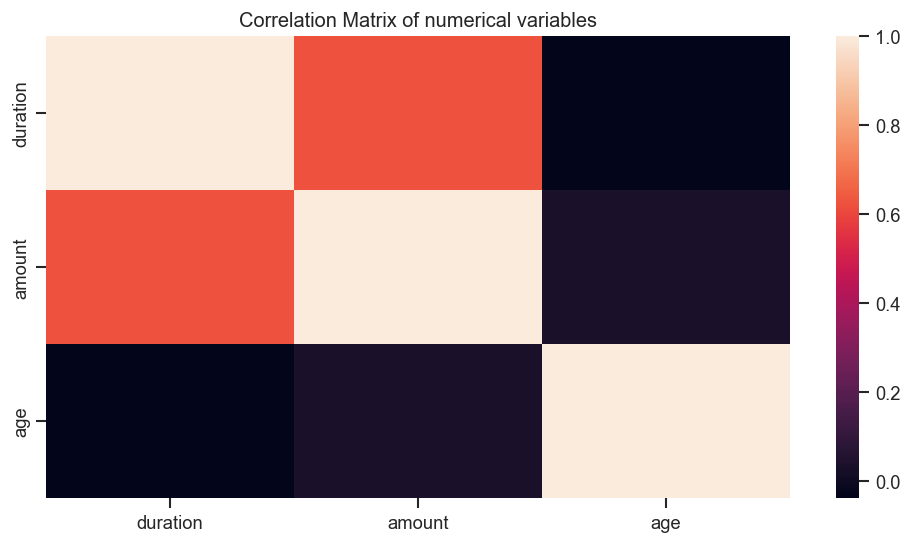

In [10]:
sns.heatmap(data=df.select_dtypes('number').corr())
plt.title('Correlation Matrix of numerical variables')

**Summary**:
- The distributions for numeric variables are somewhat right-skewed with longer tails.
- Larger loans tend to be associated with longer durations, reflecting standard loan structuring.
- Age does not seem to be a correlating factor with duration or amount.

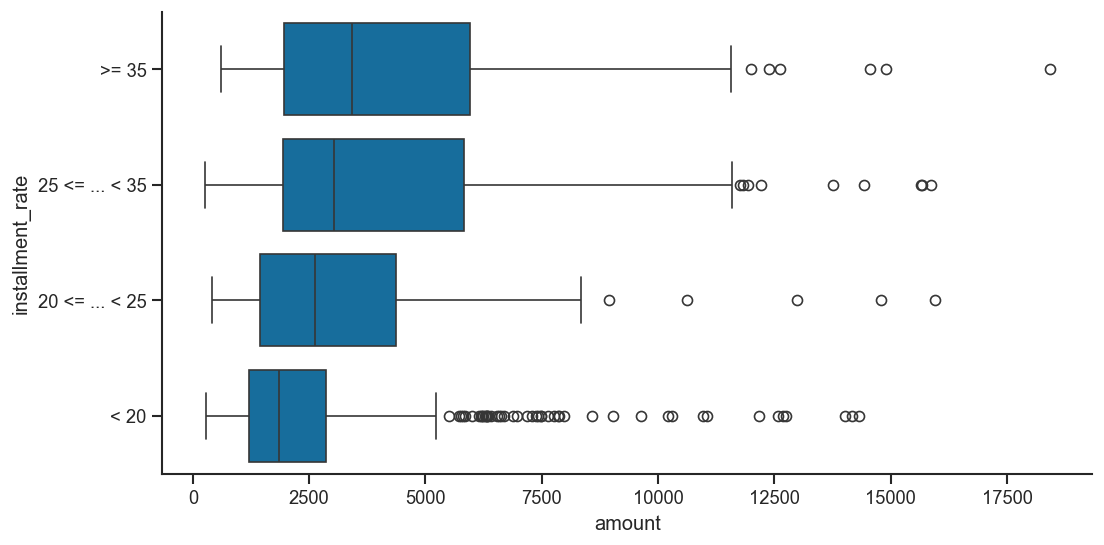

In [11]:
sns.boxplot(data=df, y='installment_rate', x='amount')
plt.show()

Higher credit amounts are associated with higher credit burden in relation to disposable income.


<Axes: xlabel='amount', ylabel='property'>

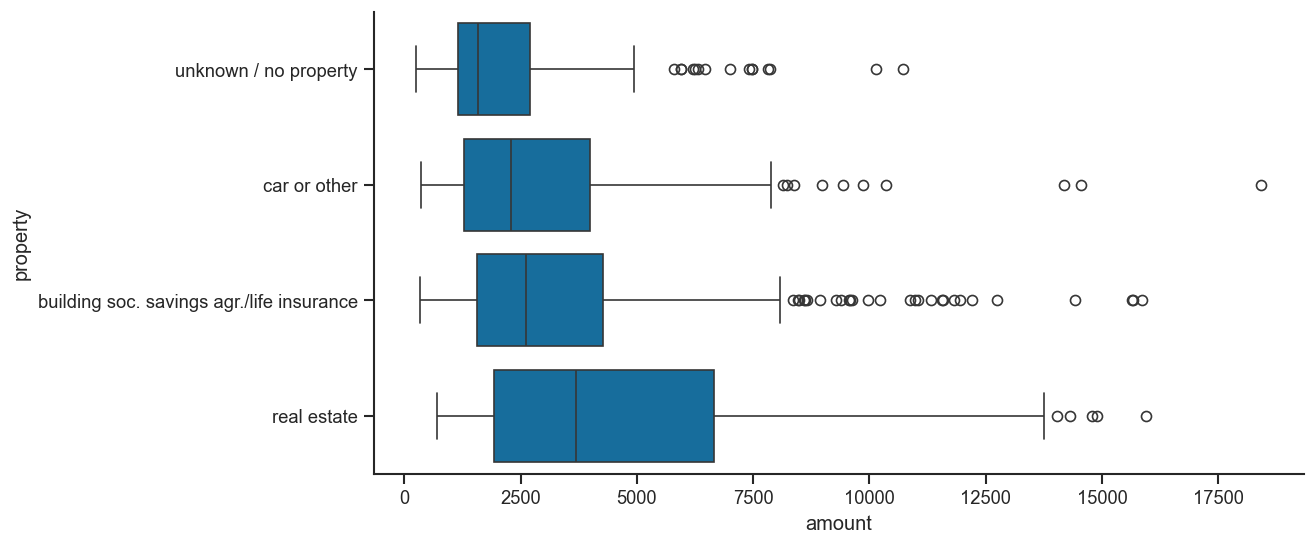

In [12]:
sns.boxplot(data=df, x='amount', y='property')

Higher valued property / collateral seems to be associated with higher credit amounts.

Purpose of credit has 11 distinct features. We group some features for robustness and readability.

<Axes: xlabel='amount', ylabel='purpose_grouped'>

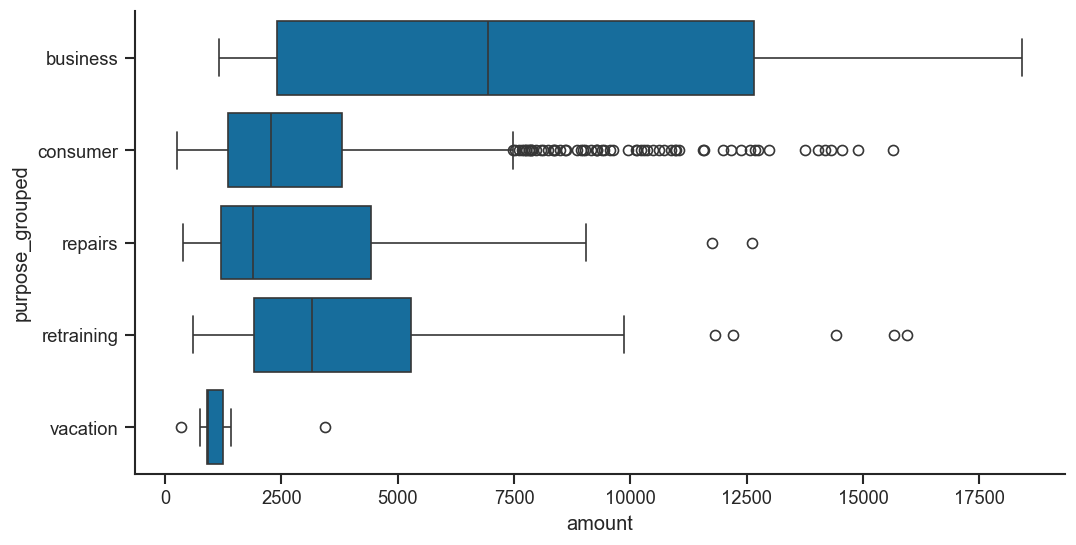

In [13]:
df['purpose_grouped'] = df['purpose'].astype('str').where(df['purpose'].isin(['repairs','education','vacation','retraining','business']),'consumer').astype('category')
sns.boxplot(data=df, y='purpose_grouped', x='amount')

Business-related purposes tend to involve higher loan amounts, which aligns with economic expectations. However, note the bandwidth of loan amounts is quite large in this category.
Other credit types cover far smaller ranges, with consumer credits having a large quantity of outliers.

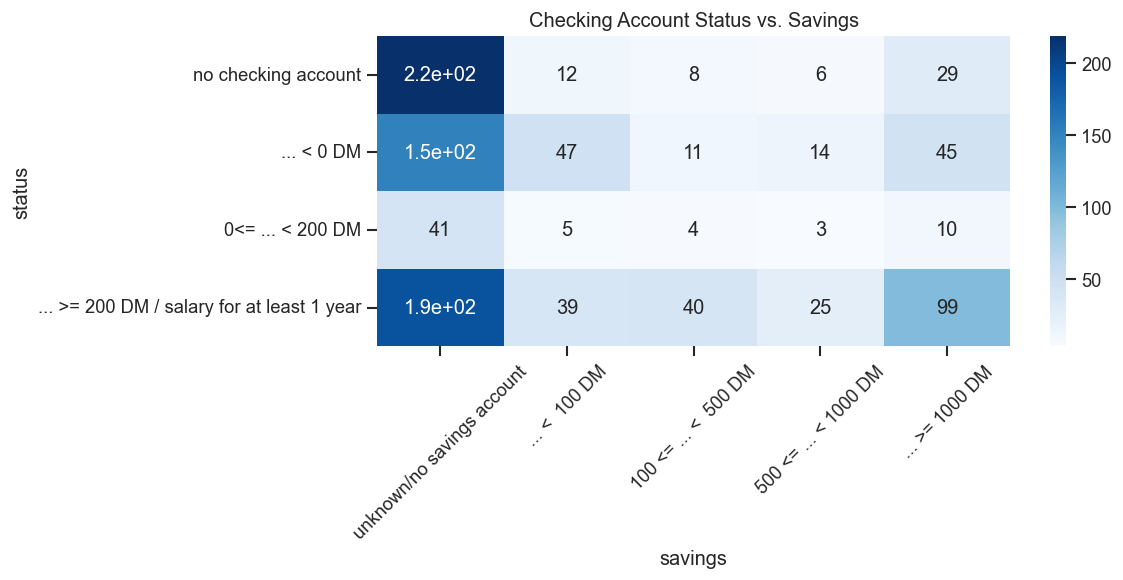

In [14]:
ct = pd.crosstab(df["status"], df["savings"])
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Checking Account Status vs. Savings")
plt.xticks(rotation=45)
plt.tight_layout()


The relationship between checking account status and savings gives a combined liquidity profile of borrowers. Having no checking account and no known savings account is the most common combination. It should be noted that not having a checking account is by far the most prevalent in the data set, so a causality is not entirely clear.

These relationships confirm that the dataset reflects realistic lending patterns.

We now move to analyzing how these factors relate to credit risk.

## Key Risk Drivers

We now analyse how key features relate to credit risk.
Focus is placed on:
- Age
- Credit properties (amount, installment rate, duration, purpose)
- Credit situation (credit history, number of credits, other installment plans)
- Financial accounts (checking account status, savings)
- Living conditions (property, housing)
- Employment (job, employment duration)


**A Note on Sensitive Features**
The dataset contains two features that warrant special attention:
`personal_status_sex` and `foreign_worker`.
Both are excluded from the risk driver analysis. Under EU anti-discrimination
law and GDPR, the use of characteristics such as gender or nationality in
credit decisions is legally restricted and may expose institutions to
regulatory and reputational risk.

### Target Variable Distribution

Understanding the balance between good and bad credit risk is essential.

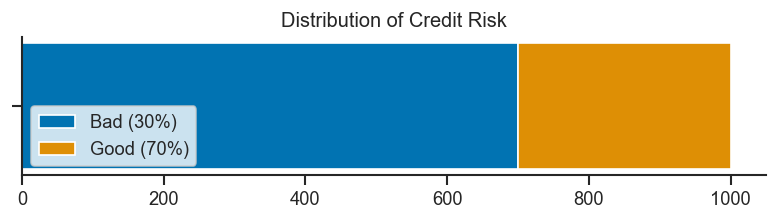

In [15]:
#risk distribution
bad = (df["credit_risk"] == "bad").mean()
counts = df["credit_risk"].value_counts()

fig, ax = plt.subplots(figsize=(8, 1.5))
ax.barh([""], counts.iloc[0], label=f"Bad ({bad:.0%})")
ax.barh([""], counts.iloc[1], left=counts.iloc[0], label=f"Good ({1-bad:.0%})")
ax.set(title="Distribution of Credit Risk")
ax.legend(loc="lower left")
plt.show()


The dataset shows a class imbalance with more good than bad credit cases.

### Credit Risk vs numerical features

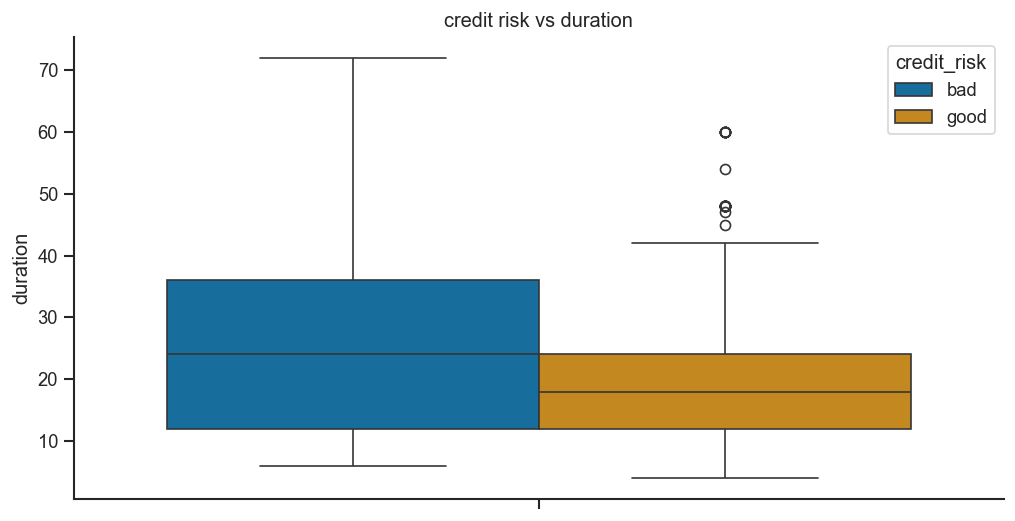

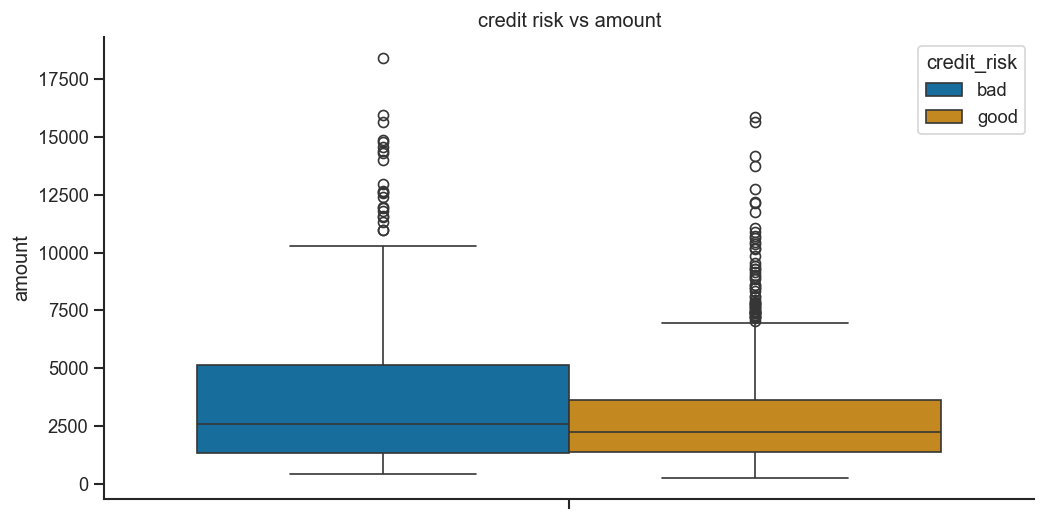

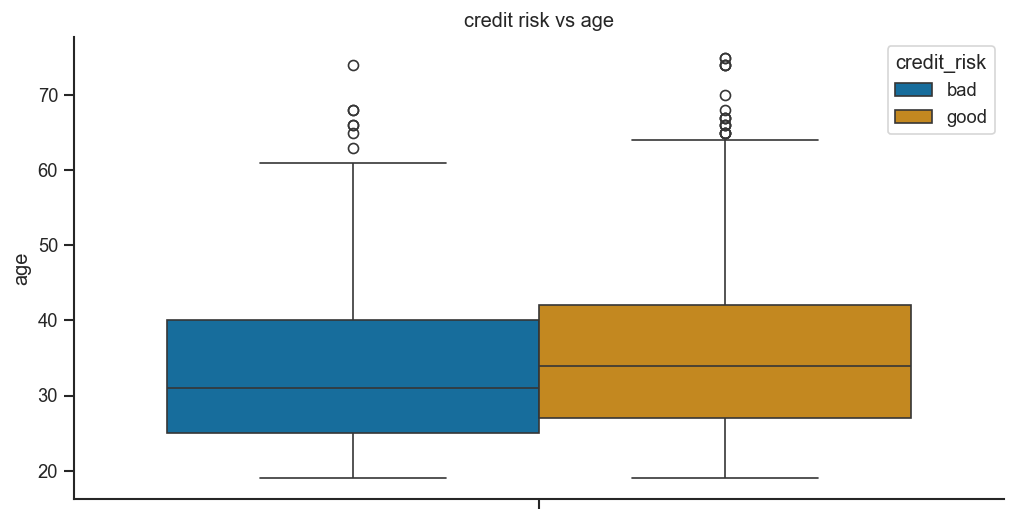

In [16]:
for col in df.select_dtypes('number').columns:
    sns.boxplot(data = df, y = col, hue='credit_risk')
    plt.title(f'credit risk vs {col}')
    plt.show()


Higher credit amounts and longer durations show a tendency toward increased risk, though overlap exists. Age does not seem to be a contributing factor.

### Credit risk vs categorical features

When analysing these features we have to take into account the prior distribution of 70% good vs. 30% bad credit risk.

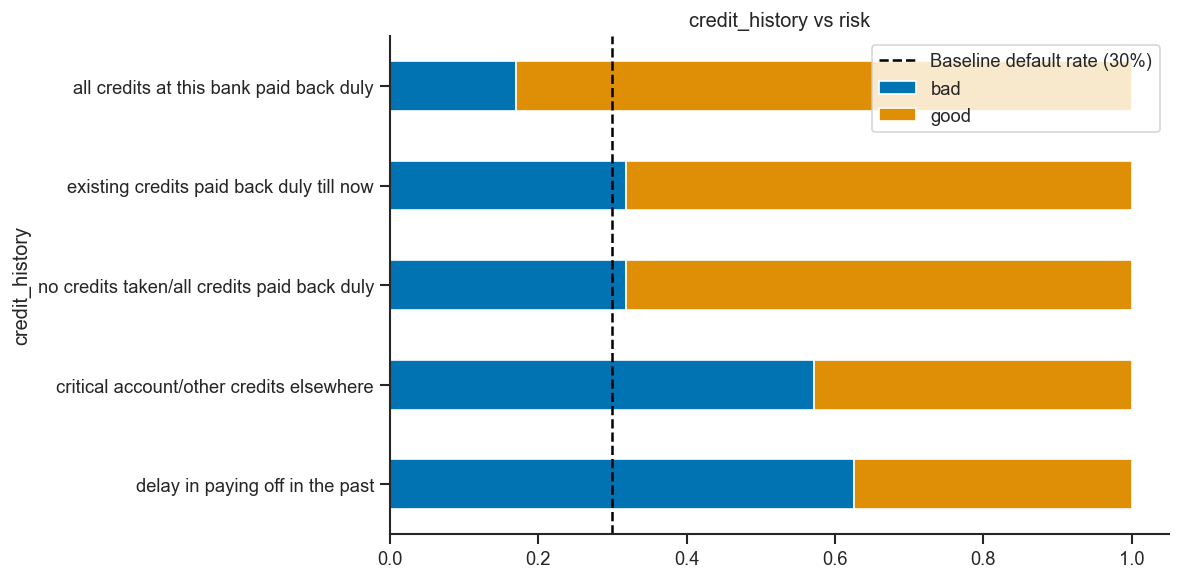

credit_risk                                       bad      good
credit_history                                                 
delay in paying off in the past              0.625000  0.375000
critical account/other credits elsewhere     0.571429  0.428571
no credits taken/all credits paid back duly  0.318868  0.681132
existing credits paid back duly till now     0.318182  0.681818
all credits at this bank paid back duly      0.170648  0.829352


In [17]:
#credit history
ctbplot(df, 'credit_history')

Compared to the baseline default rate of around 30%, borrowers with a history of delayed payments show substantially higher risk, while those with a clean repayment history exhibit significantly lower default rates.

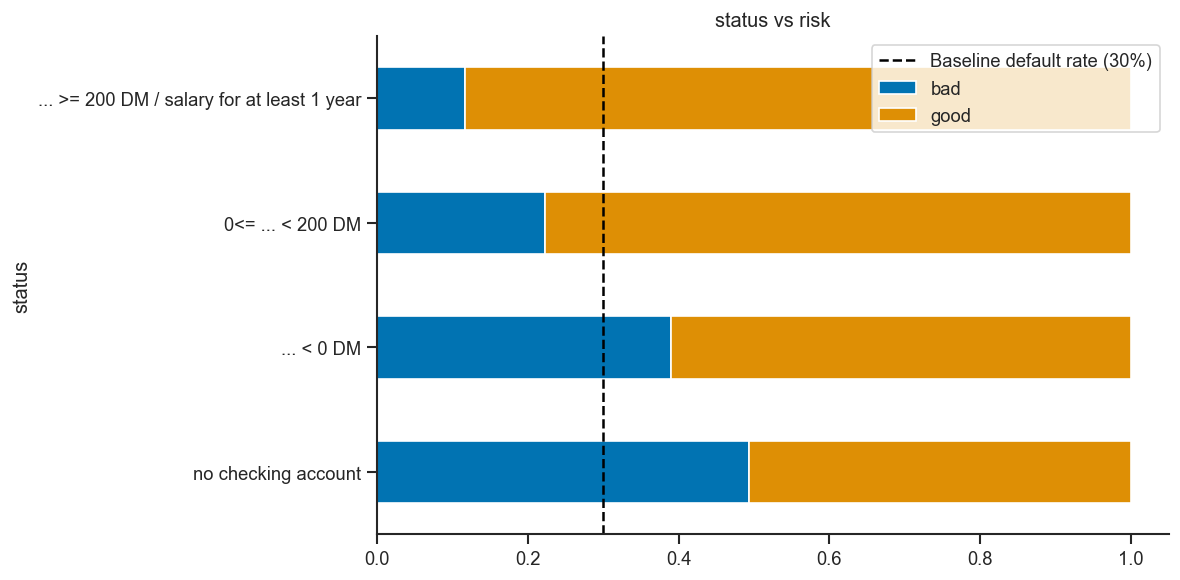

credit_risk                                      bad      good
status                                                        
no checking account                         0.492701  0.507299
... < 0 DM                                  0.390335  0.609665
0<= ... < 200 DM                            0.222222  0.777778
... >= 200 DM / salary for at least 1 year  0.116751  0.883249


In [18]:
#status
ctbplot(df, 'status')

Borrowers with no checking account or negative balance show increased risk, while those with a positive balance show a decrease of risk. Status seems to be a good indicator of risk.

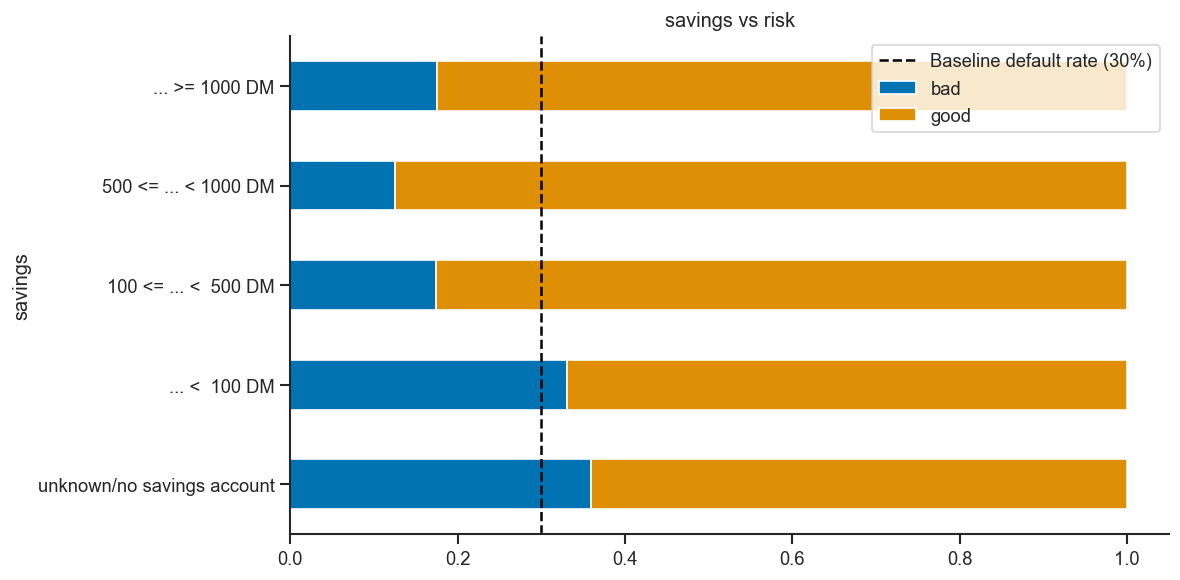

credit_risk                      bad      good
savings                                       
unknown/no savings account  0.359867  0.640133
... <  100 DM               0.330097  0.669903
100 <= ... <  500 DM        0.174603  0.825397
500 <= ... < 1000 DM        0.125000  0.875000
... >= 1000 DM              0.174863  0.825137


In [19]:
#savings
ctbplot(df, 'savings')

Savings seem to have a significant impact on risk as different categories deviate greatly compared to the baseline for borrowers with more than 100 DM in their account.

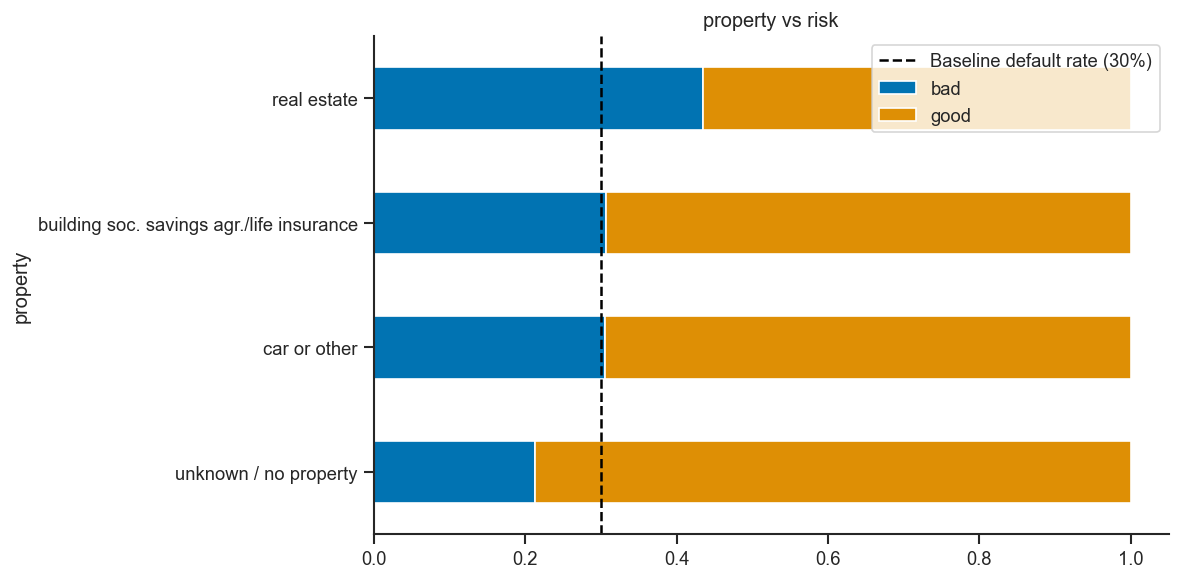

credit_risk                                     bad      good
property                                                     
unknown / no property                      0.212766  0.787234
car or other                               0.306034  0.693966
building soc. savings agr./life insurance  0.307229  0.692771
real estate                                0.435065  0.564935


In [20]:
#property
ctbplot(df, 'property')

Borrowers with unknown or no property show an increase in risk, while real estate owners show significantly less risk.

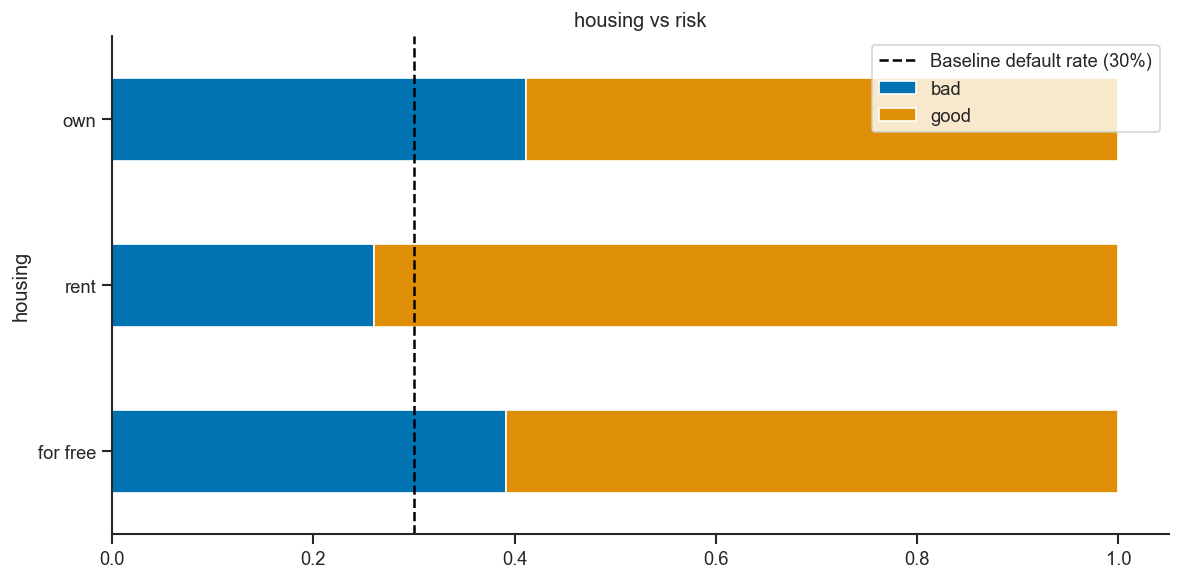

credit_risk       bad      good
housing                        
for free     0.391061  0.608939
rent         0.260504  0.739496
own          0.411215  0.588785


In [21]:
#housing
ctbplot(df, 'housing')

Livin in one's own property or for free seems to have a negative impact on risk.

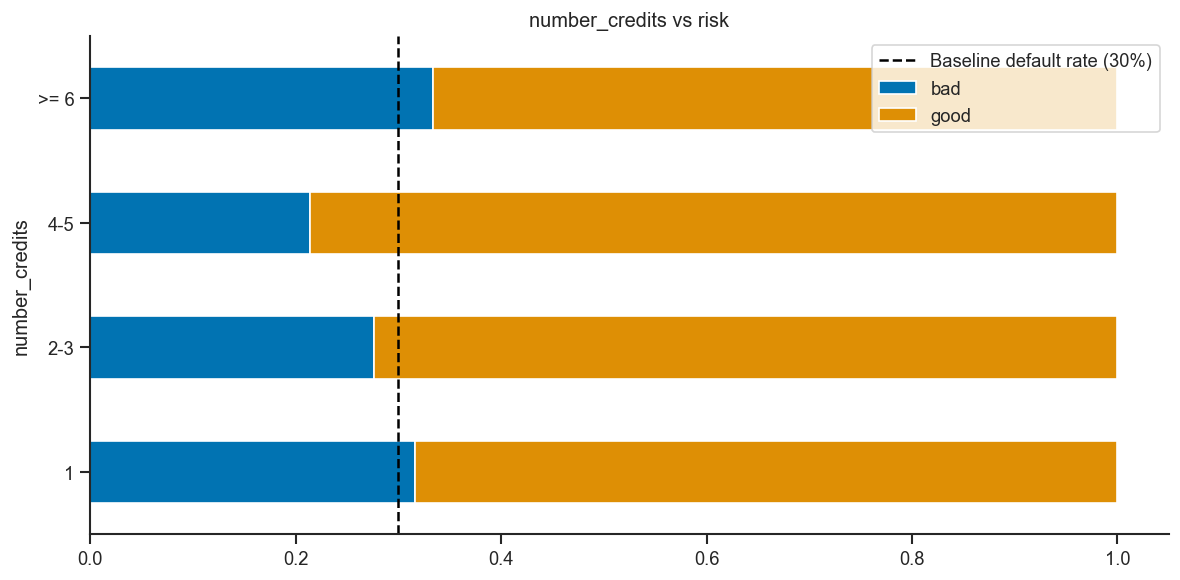

credit_risk          bad      good
number_credits                    
1               0.315956  0.684044
2-3             0.276276  0.723724
4-5             0.214286  0.785714
>= 6            0.333333  0.666667


In [22]:
#number credits
ctbplot(df, 'number_credits')

Borrowers with 4-5 credits actually show less risk, than those with fewer or more credits. This contradicts intuition.

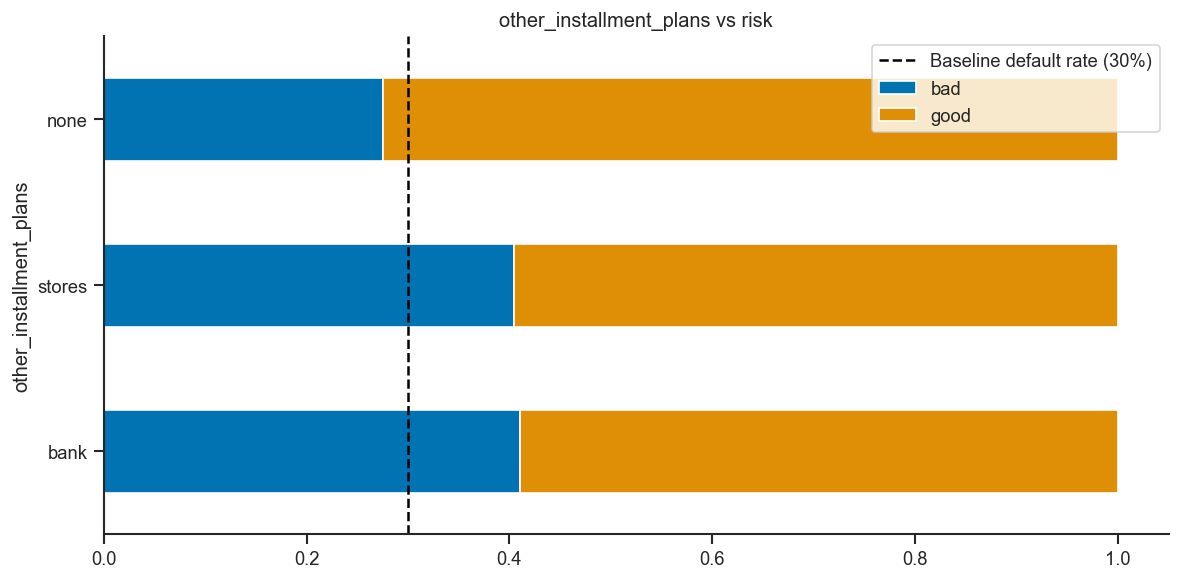

credit_risk                   bad      good
other_installment_plans                    
bank                     0.410072  0.589928
stores                   0.404255  0.595745
none                     0.275184  0.724816


In [23]:
#other_installment_plans
ctbplot(df, 'other_installment_plans')

Having other installment plans at banks or stores has a sizable impact on risk.

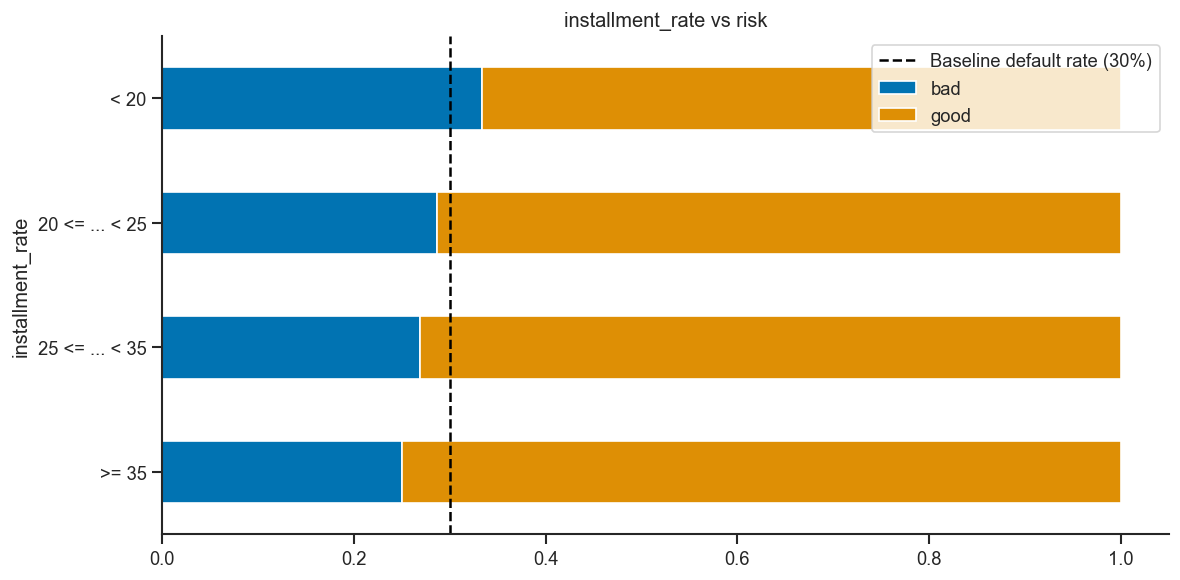

credit_risk            bad      good
installment_rate                    
>= 35             0.250000  0.750000
25 <= ... < 35    0.268398  0.731602
20 <= ... < 25    0.286624  0.713376
< 20              0.334034  0.665966


In [24]:
#installment rate
ctbplot(df, 'installment_rate')

Credit amount in relation to disposable income does not seem to have a significant impact on credit risk.

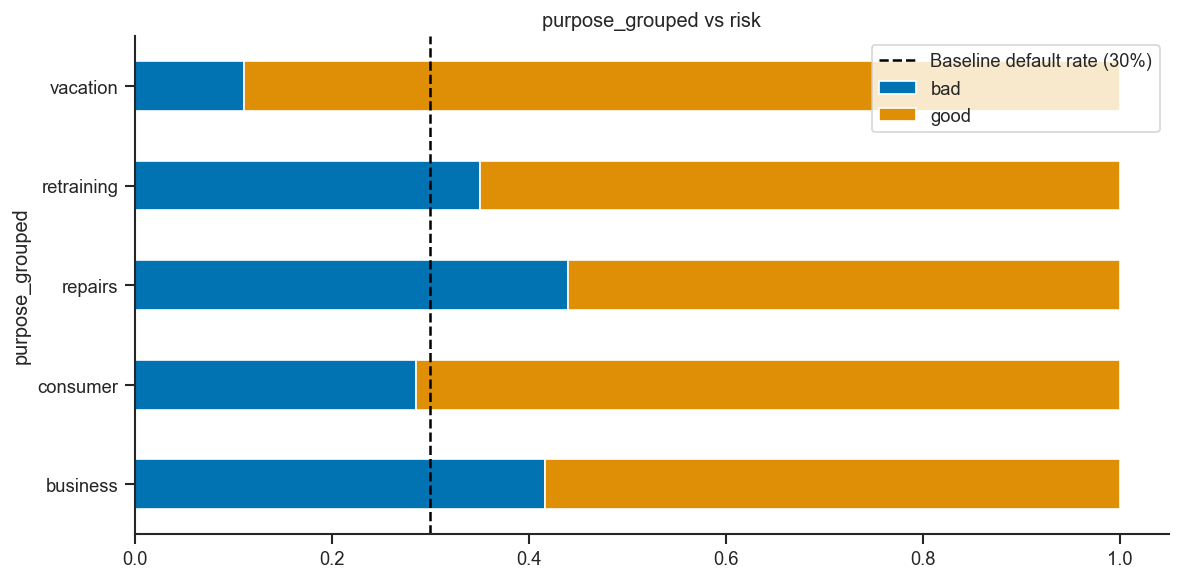

credit_risk           bad      good
purpose_grouped                    
business         0.416667  0.583333
consumer         0.286058  0.713942
repairs          0.440000  0.560000
retraining       0.350515  0.649485
vacation         0.111111  0.888889


In [25]:
#purpose_grouped
ctbplot(df, 'purpose_grouped')

Credit purpose seems to have a significant impact on risk as different categories deviate greatly compared to the baseline.

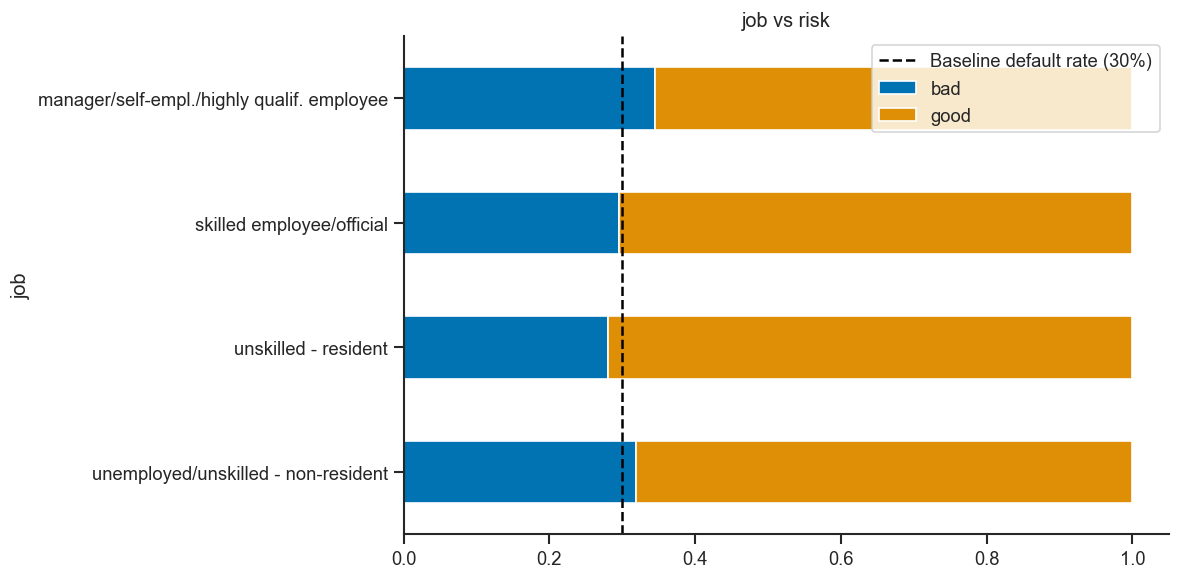

credit_risk                                      bad      good
job                                                           
unemployed/unskilled - non-resident         0.318182  0.681818
unskilled - resident                        0.280000  0.720000
skilled employee/official                   0.295238  0.704762
manager/self-empl./highly qualif. employee  0.344595  0.655405


In [26]:
#job
ctbplot(df, 'job')

Job Type does not seem to play a significant role in determining credit risk. Borrowers in the highest skill however show a slight improvement on risk.

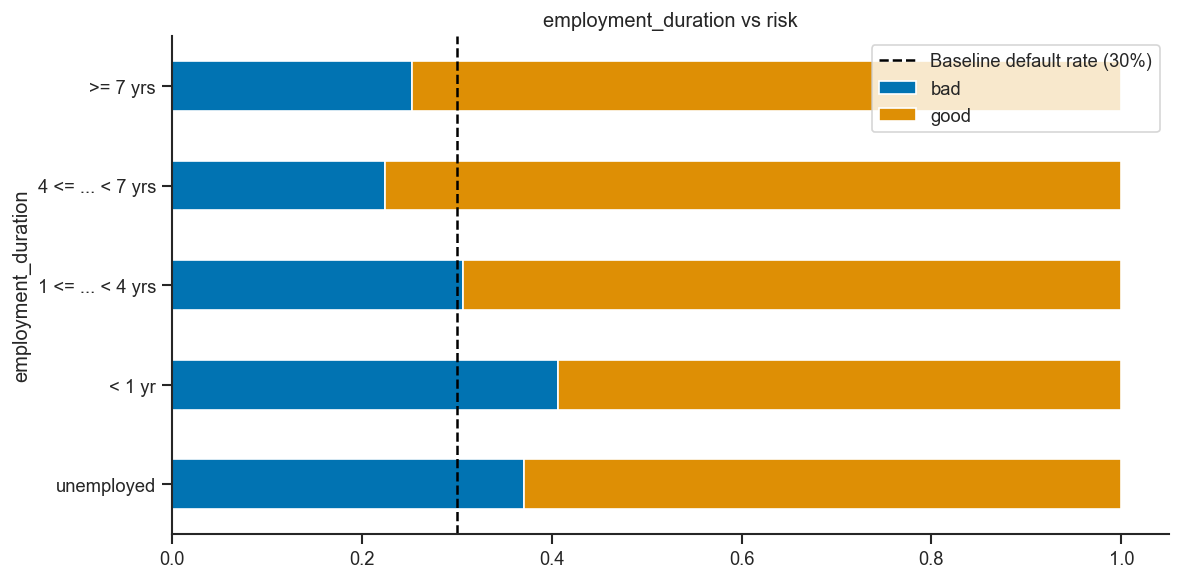

credit_risk               bad      good
employment_duration                    
unemployed           0.370968  0.629032
< 1 yr               0.406977  0.593023
1 <= ... < 4 yrs     0.306785  0.693215
4 <= ... < 7 yrs     0.224138  0.775862
>= 7 yrs             0.252964  0.747036


In [27]:
#employment duration
ctbplot(df, 'employment_duration')

Higher employment durations seem to be associated with lower risk. However, this relationship does not seem to be linear.

## Statistical Summary

We complement the exploratory analysis with statistical tests and effect sizes, using Cohen's d and Cramer's V,
to assess the strength of relationships between features and credit risk.

In [28]:
features = [col for col in df.columns if col not in ['credit_risk', 'purpose']]

results = pd.DataFrame([analyse_feature(df, col) for col in features], index=features)
results.sort_values('effect_size', ascending=False, inplace=True)
results_filtered = results[(results['effect_size'] > 0.1) & (results['p_value']<0.05)]
results_filtered

,type,test,p_value,effect_size,significance,n,interpretation
duration,numerical,t-test,2.404081e-10,0.462182,***,1000,moderate effect
status,categorical,chi-square,1.218902e-26,0.351740,***,1000,strong association
amount,numerical,t-test,2.477103e-05,0.315213,***,1000,moderate effect
credit_history,categorical,chi-square,1.279187e-12,0.248378,***,1000,moderate association
age,numerical,t-test,3.778175e-03,0.200240,**,1000,moderate effect
savings,categorical,chi-square,2.761214e-07,0.189997,***,1000,moderate association
property,categorical,chi-square,2.858442e-05,0.154012,***,1000,moderate association
housing,categorical,chi-square,8.810311e-05,0.136653,***,1000,moderate association
employment_duration,categorical,chi-square,1.045452e-03,0.135530,**,1000,moderate association
other_installment_plans,categorical,chi-square,1.629318e-03,0.113310,**,1000,moderate association


We filter for features with an effect size above 0.1 and a p-value below 0.05.
This threshold removes features that might be statistically significant but practically
negligible given the sample size, keeping only those with at least a moderate
association with credit risk.

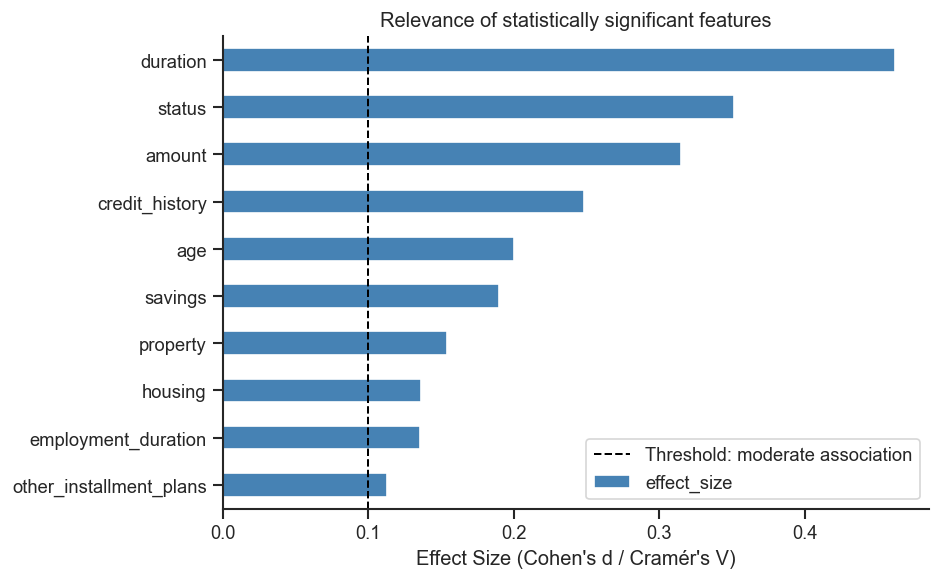

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
results_filtered['effect_size'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(0.1, color='black', linestyle='--', linewidth=1.2, label='Threshold: moderate association')
ax.set_title('Relevance of statistically significant features')
ax.set_xlabel("Effect Size (Cohen's d / Cramér's V)")
ax.legend()
plt.tight_layout()

### Statistical Significance and Effect Size

The statistical analysis shows that several features are significantly associated with credit risk, as indicated by low p-values. This confirms most of the assumptions made in the exploratory data analysis.

However, statistical significance alone is not sufficient for assessing practical relevance. Given the dataset size, even small differences can become statistically significant.

Effect sizes provide additional context by measuring the strength of these relationships. While some variables (e.g., credit history, checking account status) exhibit moderate to strong effects, many others show only weak effects despite being statistically significant.

This highlights that not all statistically significant variables are equally important from a risk management perspective.

## Summary of Key Drivers

The analysis shows that credit risk is primarily driven by:

- loan characteristics (duration and amount)
- past repayment behavior (credit history)
- short-term financial liquidity (checking account status)
- assets (savings and property)

These findings align with established credit risk frameworks, where
short-term liquidity and repayment behavior are considered the most reliable signals
of a borrower's ability and willingness to repay.

In contrast, variables such as job and installment rate show weaker individual effects.

Overall, the results suggest that credit risk cannot be explained by single variables alone, but rather emerges from the interaction of multiple factors. This aligns with real-world credit risk assessment, where decisions are based on a holistic view of the borrower rather than isolated indicators.


### Credit Risk Scoring & Business Value Optimization

In retail banking, credit risk models must be highly interpretable and transparent to satisfy regulatory requirements and support automated credit decisions. We implement a **Logistic Regression model** using **Weight of Evidence (WoE)** encoding. This methodology is the foundation of traditional **Credit Scorecards**, as it:
- Discretizes numerical features into risk-homogeneous bins, making the model robust to outliers and non-linearities.
- Standardizes all variables onto a common scale (WoE), where the magnitude of the coefficient directly indicates predictive power.
- Aligns with traditional credit scoring systems, allowing probabilities of default (PD) to be mapped to transparent scoring points.

We select the top key drivers identified during EDA:
1. **Short-term liquidity**: checking account status (`status`)
2. **Repayment history**: credit history (`credit_history`)
3. **Financial assets**: savings account status (`savings`)
4. **Collateral**: property type (`property`)
5. **Customer demographics**: age (`age`, binned)
6. **Loan risk**: credit duration (`duration`, binned)
7. **Loan amount** credit amount (`amount`, binned)


In [36]:
# 1. Prepare data and target variable (1 = bad/default, 0 = good/repayment)
df_model = df[['status', 'credit_history', 'savings', 'property', 'age', 'duration', 'amount','credit_risk']].copy()
df_model['target'] = (df_model['credit_risk'] == 'bad').astype(int)
df_model = df_model.drop(columns=['credit_risk'])

# 2. Bin numerical variables into credit risk brackets
df_model['age_bin'] = pd.cut(df_model['age'], bins=[0, 25, 35, 45, 120], labels=['<25', '25-35', '35-45', '45+'])
df_model['duration_bin'] = pd.cut(df_model['duration'], bins=[0, 12, 24, 36, 120], labels=['<12', '12-24', '24-36', '36+'])
df_model['amount_bin'] = pd.cut(df_model['amount'], bins=np.append(np.arange(0,5500,1000),20000),
labels=['<1000'] + [f'{1000*i}-{1000*(i+1)}' for i in range(1,5)] + ['5000+'])
df_model = df_model.drop(columns=['age', 'duration','amount'])

# 3. Train-test split (80/20) with stratification to maintain default rates
features = ['status', 'credit_history', 'savings', 'property', 'age_bin', 'duration_bin', 'amount_bin']
X = df_model[features]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training observations: {X_train.shape[0]} | Testing observations: {X_test.shape[0]}")
print(f"Training default rate: {y_train.mean():.2%}")

Training observations: 800 | Testing observations: 200
Training default rate: 30.00%


## Weight of Evidence (WoE) and Information Value (IV)

We calculate **Weight of Evidence (WoE)** for each category and binned interval on the training set to prevent data leakage:
$$WoE_c = \ln \left( \frac{\% \text{ Good (Non-default)}}{\% \text{ Bad (Default)}} \right)$$

- A **positive WoE** indicates a category with lower risk than the baseline portfolio (higher concentration of good borrowers).
- A **negative WoE** indicates a higher risk category (higher concentration of bad/defaulted borrowers).

We also calculate the **Information Value (IV)** to measure the overall predictive strength of each feature:
$$IV = \sum \left( \% \text{ Good} - \% \text{ Bad} \right) \times WoE$$

*Interpretation of IV in Banking:*
- $< 0.02$: Useless
- $0.02 \text{ to } 0.1$: Weak predictor
- $0.1 \text{ to } 0.3$: Medium predictor
- $0.3 \text{ to } 0.5$: Strong predictor
- $> 0.5$: Suspiciously strong (check for target leakage)


In [37]:
# Compute WoE maps and Information Value (IV) on Train Set
woe_maps = {}
iv_summary = {}

for col in features:
    # Cross-tabulate Good (0) vs Bad (1)
    counts = pd.crosstab(X_train[col], y_train)
    counts.columns = ['Good', 'Bad']
    
    # Add Laplace correction (0.5) to prevent log of zero or division by zero
    counts['Good'] = counts['Good'] + 0.5
    counts['Bad'] = counts['Bad'] + 0.5
    
    # Calculate proportions
    total_good = (y_train == 0).sum() + 0.5
    total_bad = (y_train == 1).sum() + 0.5
    
    counts['prop_good'] = counts['Good'] / total_good
    counts['prop_bad'] = counts['Bad'] / total_bad
    
    # Calculate WoE and IV per category
    counts['WoE'] = np.log(counts['prop_good'] / counts['prop_bad'])
    counts['IV'] = (counts['prop_good'] - counts['prop_bad']) * counts['WoE']
    
    woe_maps[col] = counts['WoE'].to_dict()
    iv_summary[col] = counts['IV'].sum()
    
    # Output detailed table
    print(f"\n--- Feature: {col} | Information Value (IV): {iv_summary[col]:.4f} ---")
    print(counts[['Good', 'Bad', 'WoE', 'IV']].round(4))

# Map features to WoE values
X_train_woe = pd.DataFrame()
X_test_woe = pd.DataFrame()

for col in features:
    X_train_woe[col] = X_train[col].map(woe_maps[col])
    X_test_woe[col] = X_test[col].map(woe_maps[col])



--- Feature: status | Information Value (IV): 0.7190 ---
                                             Good    Bad     WoE      IV
status                                                                  
no checking account                         107.5  110.5 -0.8736  0.2338
... < 0 DM                                  136.5   85.5 -0.3783  0.0424
0<= ... < 200 DM                             36.5   10.5  0.3998  0.0086
... >= 200 DM / salary for at least 1 year  281.5   35.5  1.2245  0.4342

--- Feature: credit_history | Information Value (IV): 0.3390 ---
                                              Good    Bad     WoE      IV
credit_history                                                           
delay in paying off in the past               13.5   20.5 -1.2638  0.0773
critical account/other credits elsewhere      18.5   24.5 -1.1270  0.0776
no credits taken/all credits paid back duly  289.5  141.5 -0.1303  0.0094
existing credits paid back duly till now      48.5   21.5 -0.0326  0

## Logistic Regression Model & Scorecard Coefficients

We train a Logistic Regression model on the WoE-encoded features. Because all features are scaled to their respective WoE representation, the resulting coefficients represent the relative strength of each feature:
- A negative coefficient indicates that higher WoE (lower default probability) leads to lower target probability (predicting bad = 0).
- The intercept represents the baseline odds of the portfolio.


In [32]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_woe, y_train)

# Create coefficient summary table
coef_summary = pd.DataFrame({
    'Feature': features,
    'Coefficient (Beta)': lr_model.coef_[0],
    'Information Value (IV)': [iv_summary[f] for f in features]
}).sort_values(by='Information Value (IV)', ascending=False)

print("Intercept:", round(lr_model.intercept_[0], 4))
print("\nModel Coefficients vs. Information Value:")
coef_summary.round(4)


Intercept: -0.8696

Model Coefficients vs. Information Value:


,Feature,Coefficient (Beta),Information Value (IV)
0,status,-0.8003,0.7190
1,credit_history,-0.7808,0.3390
2,savings,-0.7856,0.2391
5,duration_bin,-0.5638,0.1839
6,amount_bin,-0.7038,0.1478
3,property,-0.7263,0.1267
4,age_bin,-0.6672,0.0988


## Model Performance Evaluation

We evaluate the model on the out-of-sample test set (20% holdout) using the Receiver Operating Characteristic (ROC) curve, Area Under the Curve (AUC), and classification metrics.


Test Set ROC-AUC: 0.7292
Gini Coefficient: 0.4583


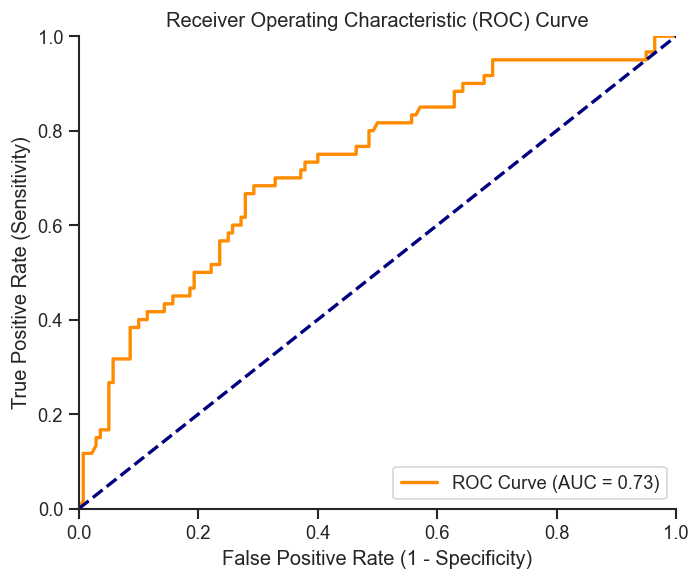


Classification Report (Threshold = 0.50):
              precision    recall  f1-score   support

        Good       0.77      0.90      0.83       140
         Bad       0.62      0.38      0.47        60

    accuracy                           0.74       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.73      0.74      0.72       200



In [33]:
# Predictions on Test Set
y_pred_prob = lr_model.predict_proba(X_test_woe)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_prob)
gini = 2 * test_auc - 1

print(f"Test Set ROC-AUC: {test_auc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_auc:.2f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Classification Report at default threshold (0.5)
print("\nClassification Report (Threshold = 0.50):")
print(classification_report(y_test, (y_pred_prob >= 0.5).astype(int), target_names=['Good', 'Bad']))


## Business Value Optimization: Asymmetric Cost Matrix

In retail lending, credit decisions are highly asymmetric:
- **False Negative (FN) of Default**: Approving a borrower who will default. This is extremely costly (capital loss of the loan amount).
- **False Positive (FP) of Default**: Rejecting a borrower who would have repaid. This results in lost interest income (opportunity cost).

Following bank-standard risk-reward trade-offs, we define an asymmetric cost matrix where:
- Cost of approving a bad borrower (FN) = **5**
- Cost of rejecting a good borrower (FP) = **1**
- Correct decisions (TP / TN) = **0**

We optimize the credit decision threshold $T$ to minimize the **Total Portfolio Credit Risk Cost** on the test set:
$$\text{Total Cost} = 5 \times \text{False Negatives} + 1 \times \text{False Positives}$$


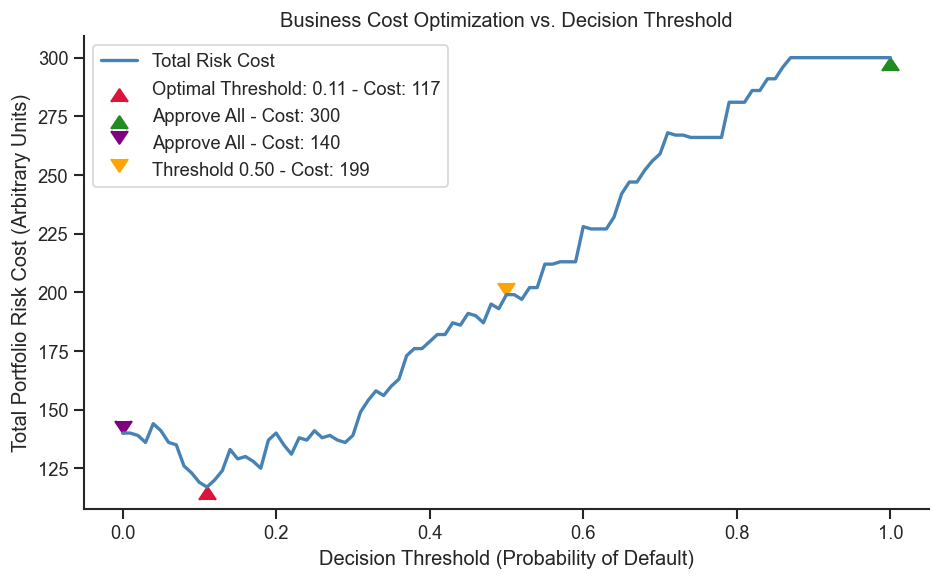

Optimal Decision Threshold: 0.11
--------------------------------------------------
Total Cost - Approve All Strategy:        300
Total Cost - Reject All Strategy:         140
Total Cost - Default Model (T = 0.50):    199
Total Cost - Optimized Model (T = 0.11):  117
--------------------------------------------------
Cost Savings vs. Approve All Strategy:    183 (61.00%)
Cost Savings vs. Default Model (T = 0.5): 82 (41.21%)


In [40]:
# Define threshold list
thresholds = np.linspace(0, 1, 101)
cost_list = []

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    fn = np.sum((y_test == 1) & (y_pred == 0))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    total_cost = 5 * fn + 1 * fp
    cost_list.append(total_cost)

optimal_idx = np.argmin(cost_list)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = cost_list[optimal_idx]

# Compare with baseline strategies
# 1. Approve Everyone (reject none)
cost_approve_all = 5 * np.sum(y_test == 1) + 1 * 0

# 2. Reject Everyone (approve none)
cost_reject_all = 5 * 0 + 1 * np.sum(y_test == 0)

# 3. Standard Threshold (0.50)
y_pred_50 = (y_pred_prob >= 0.5).astype(int)
fn_50 = np.sum((y_test == 1) & (y_pred_50 == 0))
fp_50 = np.sum((y_test == 0) & (y_pred_50 == 1))
cost_50 = 5 * fn_50 + 1 * fp_50

# Plot Cost Curve vs. Threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, cost_list, color='steelblue', lw=2, label='Total Risk Cost')
ax.scatter(optimal_threshold, optimal_cost, color='crimson', marker = 6, s=100,
           label=f'Optimal Threshold: {optimal_threshold:.2f} - Cost: {optimal_cost}')
ax.scatter(1,cost_approve_all, color='forestgreen', marker = 6, s=100, label=f'Approve All - Cost: {cost_approve_all}')
ax.scatter(0,cost_reject_all, color='purple', marker = 7, s=100, label=f'Approve All - Cost: {cost_reject_all}')
ax.scatter(0.5,cost_50, color='orange', marker = 7, s=100, label=f'Threshold 0.50 - Cost: {cost_50}')

ax.set_title('Business Cost Optimization vs. Decision Threshold')
ax.set_xlabel('Decision Threshold (Probability of Default)')
ax.set_ylabel('Total Portfolio Risk Cost (Arbitrary Units)')
ax.legend()
plt.tight_layout()
plt.show()

# Print detailed business cost comparison
print(f"Optimal Decision Threshold: {optimal_threshold:.2f}")
print("-" * 50)
print(f"Total Cost - Approve All Strategy:        {cost_approve_all}")
print(f"Total Cost - Reject All Strategy:         {cost_reject_all}")
print(f"Total Cost - Default Model (T = 0.50):    {cost_50}")
print(f"Total Cost - Optimized Model (T = {optimal_threshold:.2f}):  {optimal_cost}")
print("-" * 50)
print(f"Cost Savings vs. Approve All Strategy:    {cost_approve_all - optimal_cost} ({((cost_approve_all - optimal_cost)/cost_approve_all):.2%})")
print(f"Cost Savings vs. Default Model (T = 0.5): {cost_50 - optimal_cost} ({((cost_50 - optimal_cost)/cost_50):.2%})")


### Confusion Matrix at Optimized Threshold

Let's inspect the confusion matrix of the model at the optimized risk threshold ($T = 0.11$).


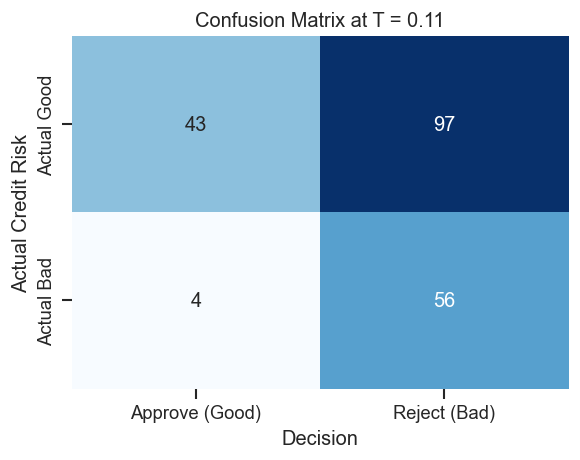

Classification Report at Optimized Threshold:
              precision    recall  f1-score   support

        Good       0.91      0.31      0.46       140
         Bad       0.37      0.93      0.53        60

    accuracy                           0.49       200
   macro avg       0.64      0.62      0.49       200
weighted avg       0.75      0.49      0.48       200



In [35]:
# Confusion Matrix at optimal threshold (0.11)
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Approve (Good)', 'Reject (Bad)'],
            yticklabels=['Actual Good', 'Actual Bad'])
ax.set_title(f'Confusion Matrix at T = {optimal_threshold:.2f}')
ax.set_ylabel('Actual Credit Risk')
ax.set_xlabel('Decision')
plt.tight_layout()
plt.show()

print("Classification Report at Optimized Threshold:")
print(classification_report(y_test, y_pred_optimal, target_names=['Good', 'Bad']))


## Value for Business

Complementing the exploratory analysis, this predictive modeling and cost optimization framework provides significant concrete value for bank risk management:

### 1. Quantification of Credit Risk Decisions
Rather than relying on qualitative rules or unweighted statistical tests, the model translates risk profiles into a single **Probability of Default (PD)**. By mapping features to transparent **Weight of Evidence (WoE)** values, credit analysts can instantly trace why a borrower has a specific risk score, satisfying both regulatory transparency and audit requirements.

### 2. Significant Capital Preservation
Moving from a naive "Approve All" lending strategy to our optimized model reduces total credit risk costs by **61.00%** (saving 183 cost units on the test set alone).
- An "Approve All" strategy leads to a default rate of 30%, incurring massive capital losses due to bad loans.
- The optimized model selectively filters out high-risk applicants, reducing the number of default occurrences from 60 to just 4 in the test set.

### 3. Asymmetric Decision Support
Standard machine learning models optimize for overall accuracy, which assumes false positives and false negatives are equally costly (a threshold of 0.5). By explicitly modeling the retail banking cost structure (where defaults cost 5x more than missed interest margins), we found that the **optimal decision threshold is 0.11**.
- Using the standard threshold (0.5) results in a risk cost of **199**.
- Shifting to the optimized threshold (0.11) reduces risk costs to **117**, representing a **41.21% cost reduction** compared to a standard machine learning model.
- This demonstrates that **aligning the model decision boundary with business economics yields significantly higher business value than technical model tuning alone**.
